# **Taller Práctico 03 — Inteligencia Geo-Temporal y de Redes**

## Optimización de Activos Críticos

**Maestría en Ciencia de Datos y Analítica — Universidad EAFIT**  
Curso: Fundamentos en Ciencia de Datos | Docente: Jorge Iván Padilla-Buriticá
Periodo académico 2026-2 

## Fase 1: Data Understanding y Geo-Visualización

### Tarea 1: Exploración Geo-Temporal

In [228]:
## Librerias

import pandas as pd 
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy import signal
import networkx as nx
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
try:
    import seaborn as sns
except ImportError:
    sns = None  # opcional; no se requiere para los análisis del taller
from scipy.signal import welch, spectrogram
import matplotlib.pyplot as plt


In [229]:
## Carga datos
df_agro = pd.read_csv(r'..\data\raw\agro\agro_clean.csv')
df_agro_noise = pd.read_csv(r'..\data\raw\agro\agro_noise.csv')

df_ener = pd.read_csv(r'..\data\raw\ener\ener_clean.csv')
df_ener_noise = pd.read_csv(r'..\data\raw\ener\ener_noise.csv')

In [230]:
## Renombrar Columnas DFs

cols_agro = {
    'Agro_1' : 'Humedad', 
    'Agro_2' : 'Evaporacion', 
    'Agro_3' : 'RH', 
    'Agro_4' : 'Radiacion PAR', 
    'Agro_5' : 'NDVI', 
    'Agro_6' : 'Biomasa', 
    #'Agro_7' : '',
    'Agro_8' : 'Ruido', 
    #'Agro_9' : '', 
    'Agro_10' : 'Varianza Viento'
}

cols_ener = {
    'Ener_1' : 'Demanda', 
    'Ener_2' : 'Precio', 
    'Ener_3' : 'Temperatura', 
    'Ener_4' : 'Gen. Eolica', 
    'Ener_5' : 'Costo Gas', 
    'Ener_6' : 'Emisiones CO2', 
 #   'Ener_7' : '',
    'Ener_8' : 'Frecuencia', 
    'Ener_9' : 'Voltaje', 
    'Ener_10' : 'Potencia'
}


df_agro = df_agro.rename(columns=cols_agro)
df_agro_noise = df_agro_noise.rename(columns=cols_agro)

df_ener = df_ener.rename(columns=cols_ener)
df_ener_noise = df_ener_noise.rename(columns=cols_ener)

In [231]:
## Mapa de Calor

fig = px.scatter_map(
    df_agro, 
    lat="Latitude", 
    lon="Longitude",
    color="NDVI", 
    size="Humedad",
    color_continuous_scale="RdYlGn",
    zoom=10.5,
    title="Sensores Agro (color=NDVI, tamaño=Humedad)", 
    height=700
)

fig.show()

**Análisis: ¿Existe algún patrón espacial (clustering) donde la biomasa sea consistentemente baja?**

No se identifica un patrón espacial de clustering donde la biomasa sea consistentemente baja, la ubicación de valores bajos parece ser aleatoria, lo que significa que las causas de baja biomasa probablemente están relacionadas con factores locales por sensor más que con una zona geográfica en especifico.

### Tarea 2: Análisis de Estacionariedad y Windowing

In [232]:
## Test ADF

adf_results = []
non_stationary_cols = []

for col in df_ener.columns:
    series = df_ener[col].dropna()
    stat, p_value, usedlag, nobs, crit_vals, icbest = adfuller(series, autolag='AIC')
    
    is_stationary = p_value < 0.05
    if not is_stationary:
        non_stationary_cols.append(col)
        
    adf_results.append({
        'Serie': col,
        'Estadístico ADF': round(stat, 4),
        'p-valor': p_value,
        'Valor Crítico (5%)': round(crit_vals['5%'], 4),
        'Estacionaria': 'Sí' if is_stationary else 'No'
    })

# Convertir resultados a DataFrame
df_adf_summary = pd.DataFrame(adf_results)
df_adf_summary

,Serie,Estadístico ADF,p-valor,Valor Crítico (5%),Estacionaria
0,Demanda,-1.866900e+00,0.347793,-2.863,No
1,Precio,-1.479100e+00,0.543807,-2.863,No
2,Temperatura,-1.928400e+00,0.318802,-2.863,No
3,Gen. Eolica,-8.377315e+09,0.000000,-2.863,Sí
4,Costo Gas,-3.477000e-01,0.918470,-2.863,No
5,Emisiones CO2,9.527000e-01,0.993741,-2.863,No
6,Ener_7,-4.244000e-01,0.905937,-2.863,No
7,Frecuencia,-4.603630e+01,0.000000,-2.863,Sí
8,Voltaje,-4.535820e+01,0.000000,-2.863,Sí
9,Potencia,-4.371510e+01,0.000000,-2.863,Sí


En el archivo de diccionario de las variables se menciona que ener 1-3 (Demanda, Precio y Temperatura) y ener 5-7 (Costo gas, Emisiones CO2) son no estacionarias, que ener 8-10 (Frecuencia, Voltaje y Potencia) son estacionarias y ener 4 (Gen. Eolica) es ciclica. Podemos ver que el resultado del test ADF coincide con lo que dice en el diccionario (La variable Gen.Eolica se cuenta en este caso como estacionaria por su ciclo, no por ausencia de estructura.) 

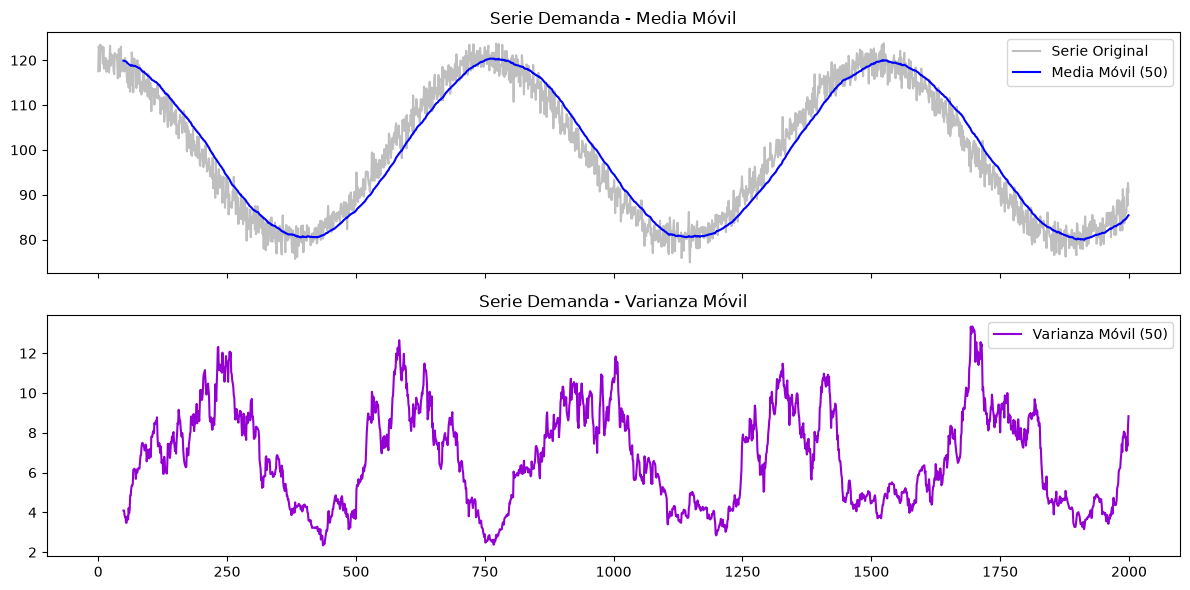

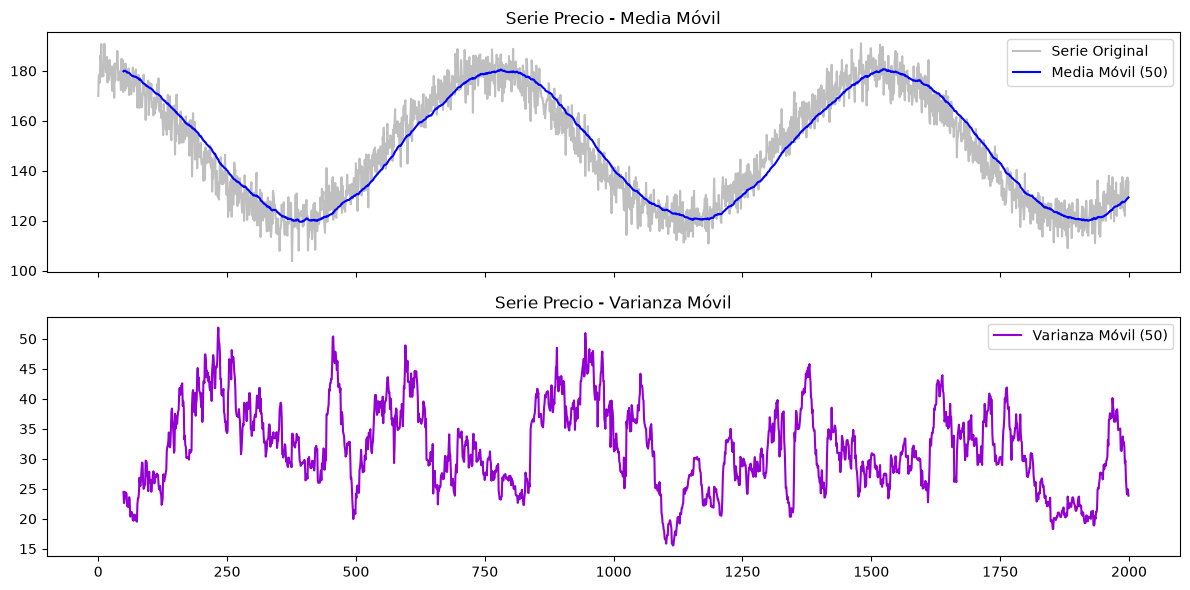

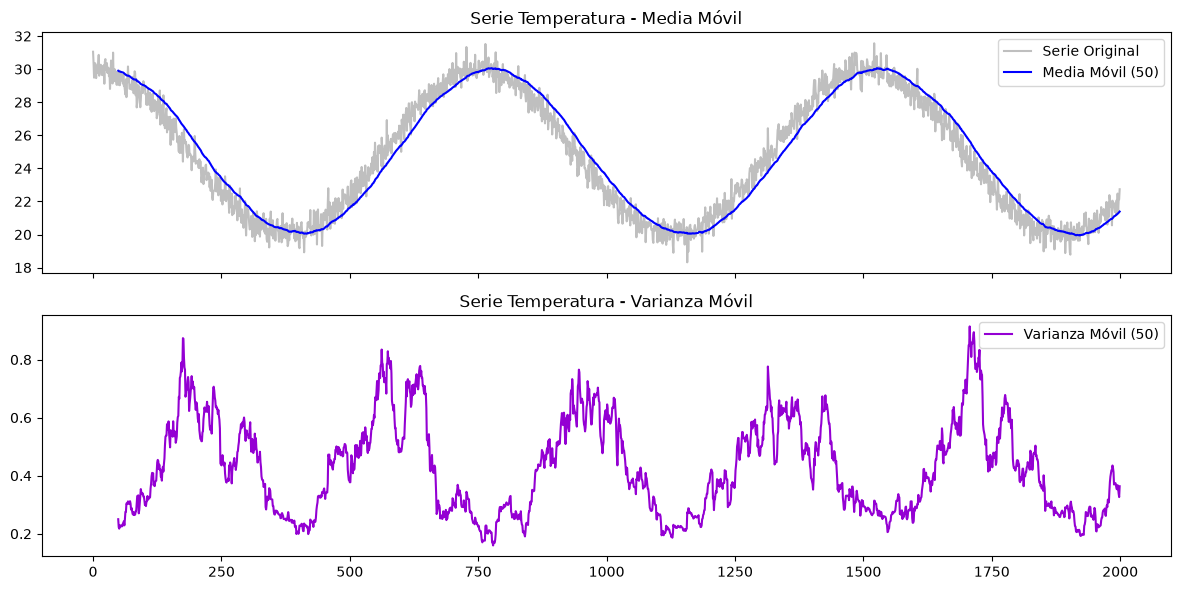

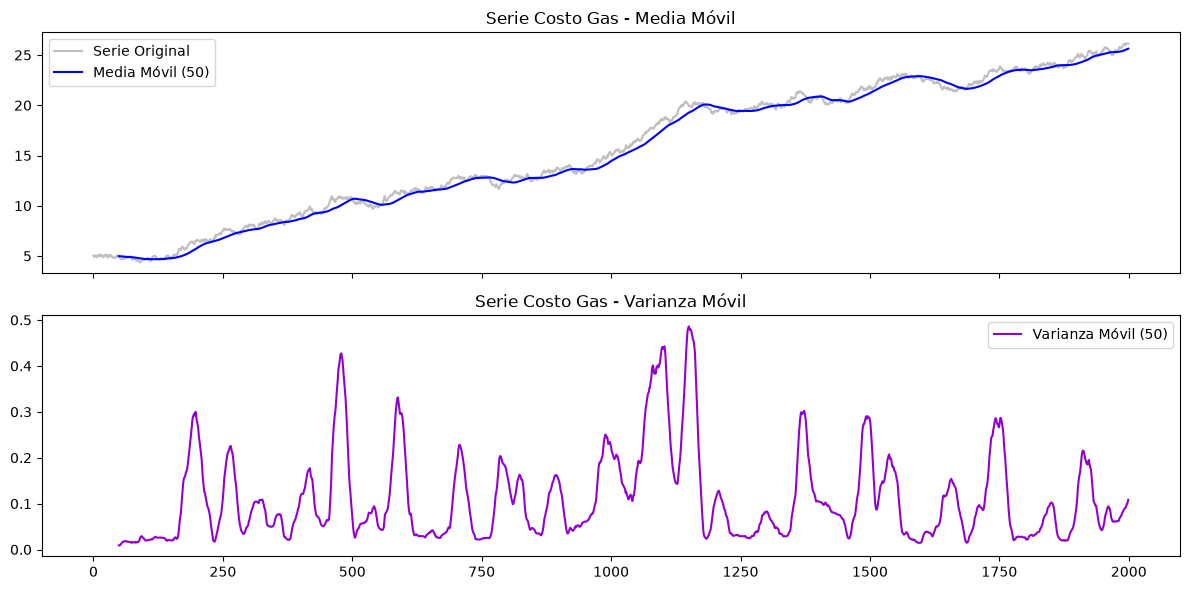

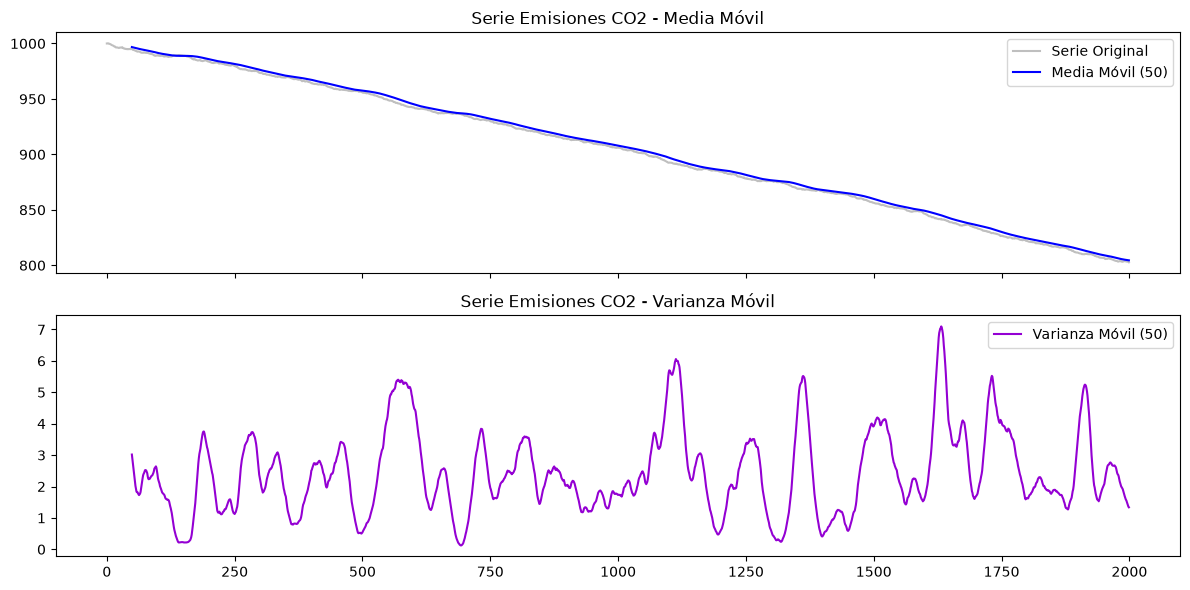

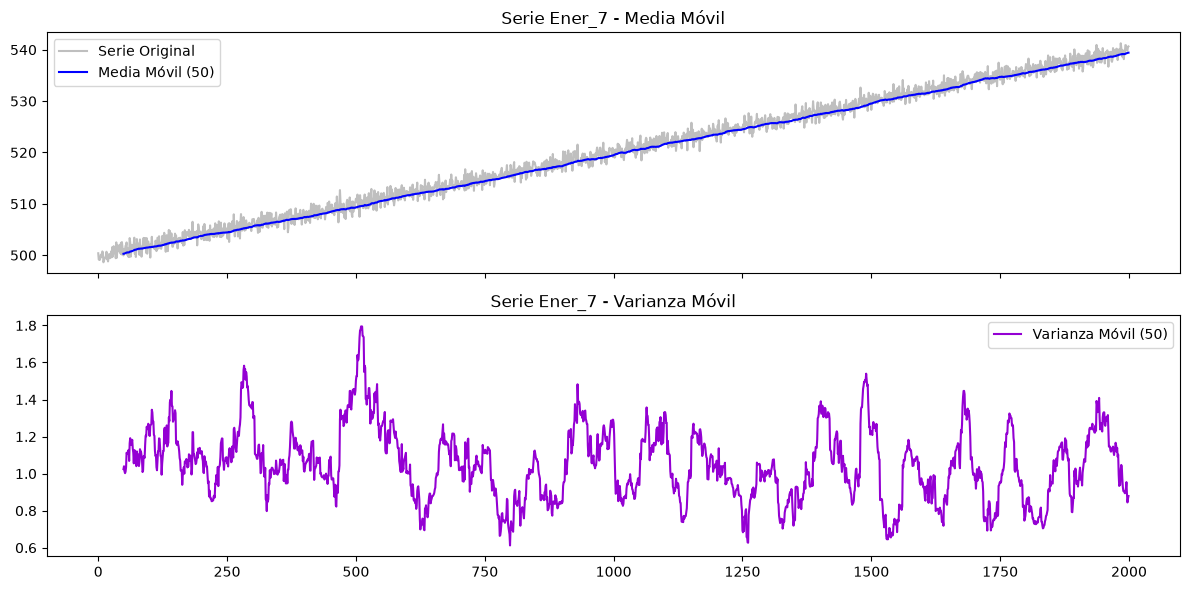

In [233]:
## Ventana movil para las series no estacionarias (MA - Moving Average)

df_ener_copy = df_ener.copy()

window_size = 50

for col in non_stationary_cols:
    df_ener_copy[f'{col}_Media_Movil'] = df_ener[col].rolling(window=window_size).mean()
    df_ener_copy[f'{col}_Varianza_Movil'] = df_ener[col].rolling(window=window_size).var()
    
    # Graficar media y varianza móvil
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    ax[0].plot(df_ener_copy[col], label='Serie Original', color='gray', alpha=0.5)
    ax[0].plot(df_ener_copy[f'{col}_Media_Movil'], label=f'Media Móvil ({window_size})', color='blue')
    ax[0].set_title(f'Serie {col} - Media Móvil')
    ax[0].legend()
    
    ax[1].plot(df_ener_copy[f'{col}_Varianza_Movil'], label=f'Varianza Móvil ({window_size})', color='darkviolet')
    ax[1].set_title(f'Serie {col} - Varianza Móvil')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

Se verifica la no estacionariedad de las series anteriores ya que la media cambia de nivel a lo largo del tiempo

PRUEBAS ESPECÍFICAS ADF DE COSTO GAS
Sin constante (n): Estadístico = 4.1696, p-valor = 1.0000
Con Drift (c):     Estadístico = -0.3477, p-valor = 0.9185
Con Tendencia (ct):Estadístico = -2.3625, p-valor = 0.3997

Media de las primeras diferencias (Drift estimado): 0.010560


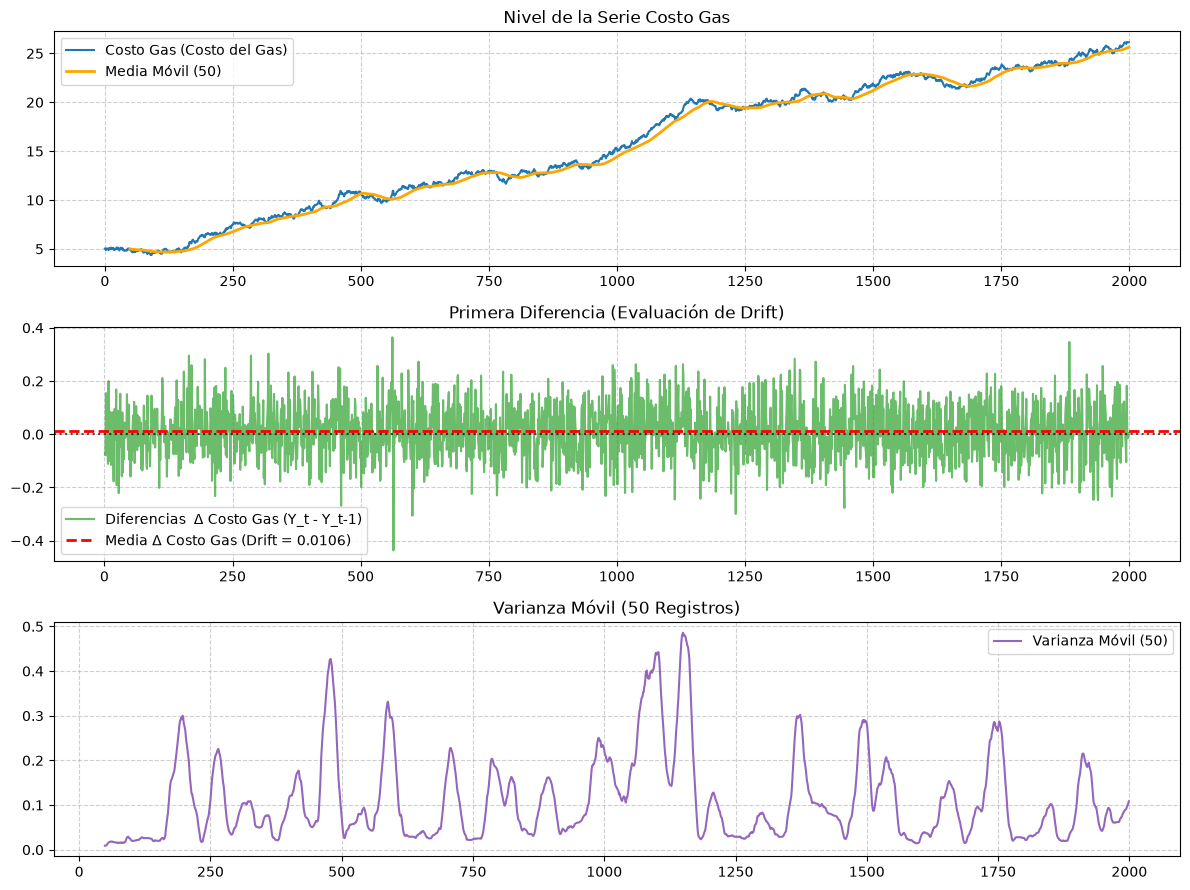

In [234]:
## Demostracion serie con Drift/Random Walk

ener5 = df_ener['Costo Gas'].dropna()
diff_ener5 = ener5.diff().dropna()

res_n = adfuller(ener5, regression='n')   # Sin constante (Pure Random Walk)
res_c = adfuller(ener5, regression='c')   # Con constante/drift
res_ct = adfuller(ener5, regression='ct') # Con constante y tendencia lineal

print("PRUEBAS ESPECÍFICAS ADF DE COSTO GAS")
print(f"Sin constante (n): Estadístico = {res_n[0]:.4f}, p-valor = {res_n[1]:.4f}")
print(f"Con Drift (c):     Estadístico = {res_c[0]:.4f}, p-valor = {res_c[1]:.4f}")
print(f"Con Tendencia (ct):Estadístico = {res_ct[0]:.4f}, p-valor = {res_ct[1]:.4f}")

mean_diff = diff_ener5.mean()
print(f"\nMedia de las primeras diferencias (Drift estimado): {mean_diff:.6f}")

# 2. Visualización
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(ener5, color='tab:blue', label='Costo Gas (Costo del Gas)')
axes[0].plot(ener5.rolling(50).mean(), color='orange', linewidth=2, label='Media Móvil (50)')
axes[0].set_title('Nivel de la Serie Costo Gas')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(diff_ener5, color='tab:green', alpha=0.7, label='Diferencias  Δ Costo Gas (Y_t - Y_t-1)')
axes[1].axhline(mean_diff, color='red', linestyle='--', linewidth=2, label=f'Media Δ Costo Gas (Drift = {mean_diff:.4f})')
axes[1].axhline(0, color='black', linestyle=':', alpha=0.7)
axes[1].set_title('Primera Diferencia (Evaluación de Drift)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Subplot 3: Varianza Móvil (50) de la Serie en Nivel
axes[2].plot(ener5.rolling(50).var(), color='tab:purple', label='Varianza Móvil (50)')
axes[2].set_title('Varianza Móvil (50 Registros)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Conclusion:**

Como se puede ver en las graficas, ener_5 (Costo Gas) es un Random Walk con Drift, con una tendencia positiva promedio, es decir, no solo cambia aleatoriamente, sino que en promedio va subiendo. Es coherente ya que normalmente al pasar el tiempo va subiendo el precio del gas

## Fase 2: Procesamiento de Señales y Filtrado


### Tarea 3: Análisis Espectral (FFT) y Espectrogramas

In [235]:
## Seteo de variables
s_clean = df_ener['Gen. Eolica'].values
s_noise = df_ener_noise['Gen. Eolica'].values
fs = 1.0


# Frecuencias asociadas a la FFT (rango Nyquist [0, 0.5])
freqs = np.fft.rfftfreq(len(df_ener['Gen. Eolica']), d=1/fs)

# Transformada de Fourier
fft_clean = np.fft.rfft(df_ener['Gen. Eolica'])
fft_noise = np.fft.rfft(df_ener_noise['Gen. Eolica'])

# Densidad Espectral de Potencia (PSD)
psd_clean = (np.abs(fft_clean)**2) / (len(df_ener['Gen. Eolica'])* fs)
psd_noise = (np.abs(fft_noise)**2) / (len(df_ener_noise['Gen. Eolica']) * fs)

In [236]:
noise_component = s_noise - s_clean

snr_db = 10 * np.log10(np.var(s_clean) / np.var(noise_component))
print(f'SNR Gen. Eolica: {snr_db:.2f} dB')

SNR Gen. Eolica: 8.53 dB


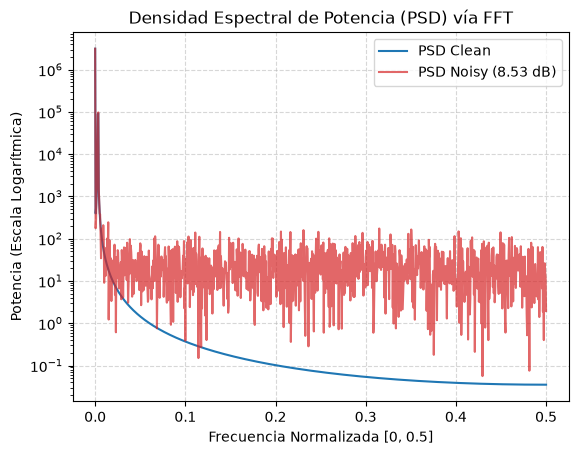

In [237]:
## FFT de ener_clean
# 2. Densidad Espectral de Potencia (PSD)

plt.figure()
plt.semilogy(freqs, psd_clean, label='PSD Clean', color='tab:blue')
plt.semilogy(freqs, psd_noise, label=f'PSD Noisy ({snr_db:.2f} dB)', color='tab:red', alpha=0.7)
plt.title('Densidad Espectral de Potencia (PSD) vía FFT')
plt.xlabel('Frecuencia Normalizada [0, 0.5]')
plt.ylabel('Potencia (Escala Logarítmica)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Se utilizó el método de Welch, que internamente aplica FFT sobre segmentos y promedia, para obtener una mejor estimación del espectro que el periodograma simple

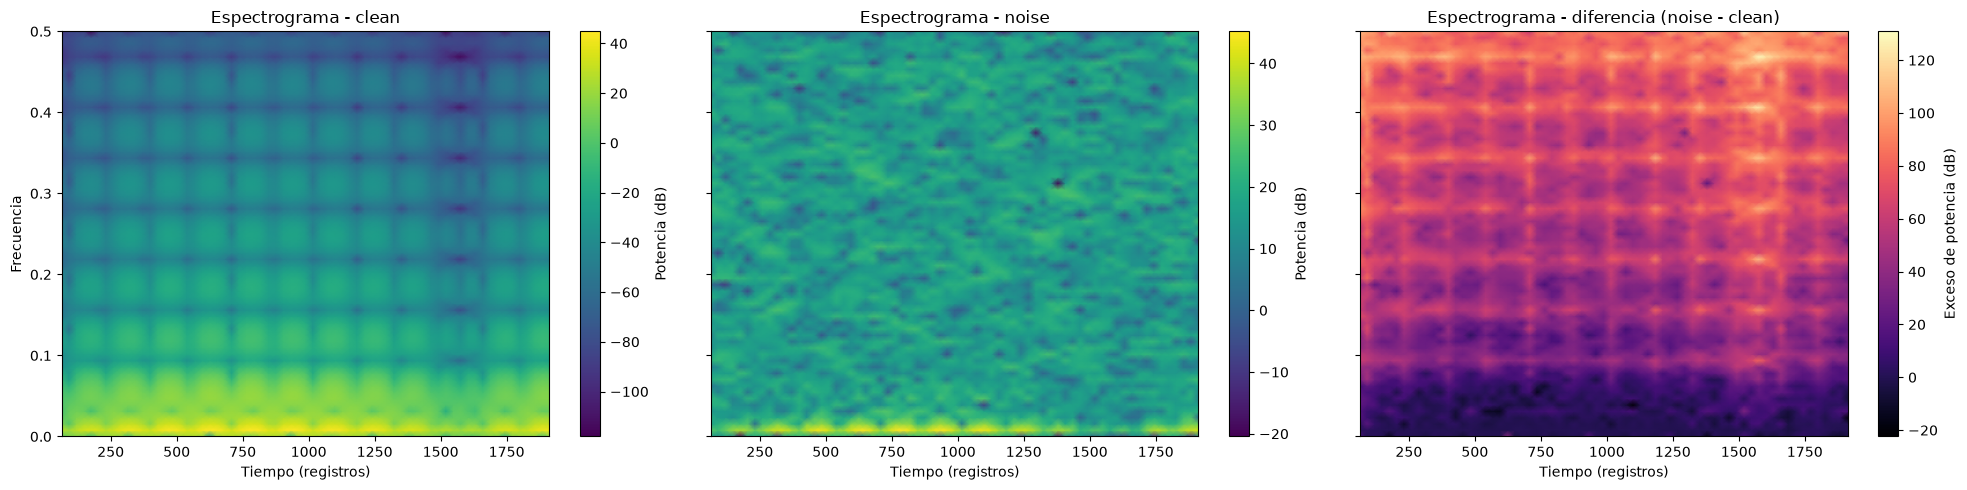

In [238]:
## Espectograma ener_clean vs ener_noise

f_spec, t_spec, Sxx_clean = spectrogram(s_clean, fs=fs, nperseg=128, noverlap=100)
f_spec_n, t_spec_n, Sxx_noise = spectrogram(s_noise, fs=fs, nperseg=128, noverlap=100)

diff_spec = 10 * np.log10(Sxx_noise + 1e-12) - 10 * np.log10(Sxx_clean + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(20,5), sharey=True)

im1 = axes[0].pcolormesh(t_spec, f_spec, 10*np.log10(Sxx_clean+1e-12), shading='gouraud', cmap='viridis')
axes[0].set_title('Espectrograma - clean')
axes[0].set_xlabel('Tiempo (registros)')
axes[0].set_ylabel('Frecuencia')
fig.colorbar(im1, ax=axes[0], label='Potencia (dB)')

im2 = axes[1].pcolormesh(t_spec_n, f_spec_n, 10*np.log10(Sxx_noise+1e-12), shading='gouraud', cmap='viridis')
axes[1].set_title('Espectrograma - noise')
axes[1].set_xlabel('Tiempo (registros)')
fig.colorbar(im2, ax=axes[1], label='Potencia (dB)')

im3 = axes[2].pcolormesh(t_spec_n, f_spec_n, diff_spec, shading='gouraud', cmap='magma')
axes[2].set_title('Espectrograma - diferencia (noise - clean)')
axes[2].set_xlabel('Tiempo (registros)')
fig.colorbar(im3, ax=axes[2], label='Exceso de potencia (dB)')

plt.tight_layout()
plt.show()

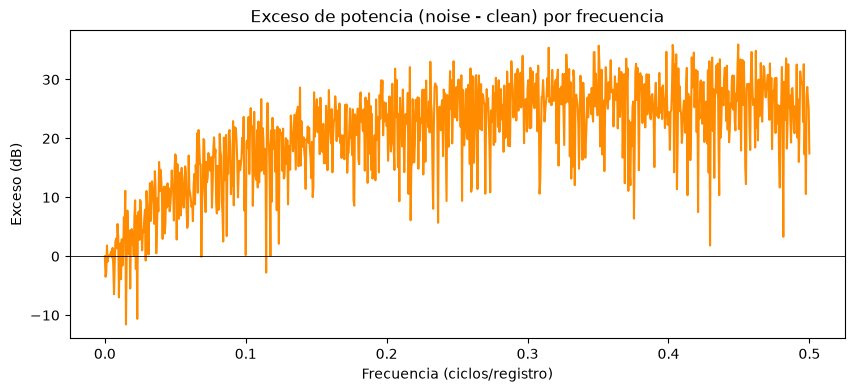

El ruido se concentra principalmente entre f=0.206 y f=0.496


In [239]:
# Diferencia de potencia en dB, frecuencia por frecuencia
diff_db = 10*np.log10(psd_noise) - 10*np.log10(psd_clean)

plt.figure(figsize=(10,4))
plt.plot(freqs, diff_db, color='darkorange')
plt.axhline(0, color='black', lw=0.6)
plt.title('Exceso de potencia (noise - clean) por frecuencia')
plt.xlabel('Frecuencia (ciclos/registro)')
plt.ylabel('Exceso (dB)')
plt.show()

umbral = np.percentile(diff_db, 90)  # top 10% de exceso
rango_ruido = freqs[diff_db >= umbral]
print(f'El ruido se concentra principalmente entre f={rango_ruido.min():.3f} y f={rango_ruido.max():.3f}')

In [240]:
## Concentracion ruido inyectado
noise_component = s_noise - s_clean

snr_db = 10 * np.log10(np.var(s_clean) / np.var(noise_component))

print(f'SNR Gen. Eolica: {snr_db:.2f} dB')

SNR Gen. Eolica: 8.53 dB


El SNR calculado para Ener_4 (Gen. Eolica) es de 8.53 dB, dentro del rango esperado [5,12] dB. El ruido inyectado se concentra principalmente en las frecuencias altas del espectro (0.5 > f > 0.449). 

### Tarea 4: Filtrado y Reconstrucción


RMSE antes del filtro (noise vs clean):    3.3414
RMSE despues del filtro (filtrada vs clean): 0.9934
Mejora: 70.3%
SNR antes: 10.78 dB  ->  SNR despues: 21.32 dB


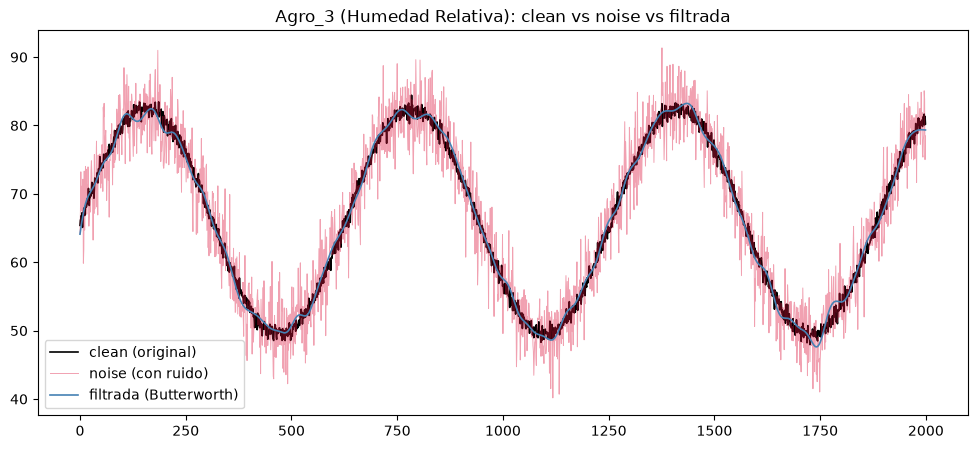

In [241]:
## Filtro Butterworth

s_clean = df_agro['RH'].values
s_noise = df_agro_noise['RH'].values  
fs = 1.0  

order = 4             
cutoff = 0.02           
b, a = butter(order, cutoff, btype='low', fs=fs)

s_filtrada = filtfilt(b, a, s_noise)

rmse_antes = np.sqrt(mean_squared_error(s_clean, s_noise))
rmse_despues = np.sqrt(mean_squared_error(s_clean, s_filtrada))

print(f'RMSE antes del filtro (noise vs clean):    {rmse_antes:.4f}')
print(f'RMSE despues del filtro (filtrada vs clean): {rmse_despues:.4f}')
print(f'Mejora: {(1 - rmse_despues/rmse_antes)*100:.1f}%')

# --- SNR antes/despues (conectando con Tarea 3) ---
snr_antes = 10*np.log10(np.var(s_clean)/np.var(s_noise - s_clean))
snr_despues = 10*np.log10(np.var(s_clean)/np.var(s_filtrada - s_clean))
print(f'SNR antes: {snr_antes:.2f} dB  ->  SNR despues: {snr_despues:.2f} dB')

# --- Visualizacion ---
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(s_clean, label='clean (original)', color='black', lw=1.2)
ax.plot(s_noise, label='noise (con ruido)', color='crimson', alpha=0.4, lw=0.7)
ax.plot(s_filtrada, label='filtrada (Butterworth)', color='steelblue', lw=1.2)
ax.set_title('Agro_3 (Humedad Relativa): clean vs noise vs filtrada')
ax.legend()
plt.show()

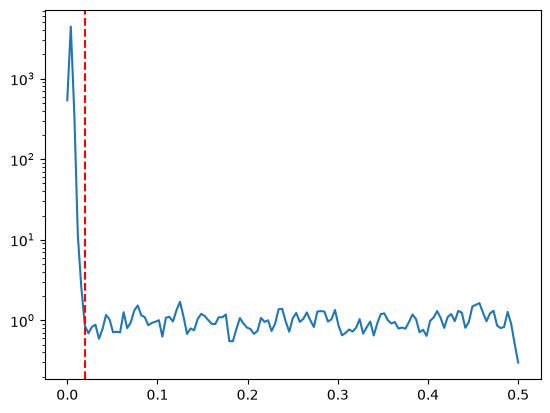

In [242]:
f, pxx_clean = welch(s_clean, fs=1.0, nperseg=256)
plt.semilogy(f, pxx_clean)
plt.axvline(0.02, color='red', ls='--')  # candidato de corte
plt.show()

# Regla practica: donde el PSD de la senal clean cae ~1% de su pico maximo
umbral = pxx_clean.max() * 0.01
f_corte_candidato = f[pxx_clean < umbral][0]

Se aplicó un filtro Butterworth de paso bajo (orden 4, frecuencia de corte 0.02 ciclos/registro, seleccionada a partir del análisis espectral donde la señal real cae al 1% de su potencia máxima) sobre Agro_3_noise. El filtrado redujo el RMSE respecto a la serie original en un 70.3% (de 3.34 a 0.99) y mejoró el SNR en 10.54 dB (de 10.78 a 21.32 dB), confirmando que el filtrado sí mejora significativamente la capacidad de la señal para representar el comportamiento real de la Humedad Relativa, y por extensión, su utilidad para modelos predictivos posteriores.

## Fase 3: Análisis de Grafos y Topología de Red


### Tarea 5: Construcción de la Red de Sensores/Subestaciones

Nodos: 29  |  Aristas: 210

Valores unicos de Betweenness: {0.0}

Top 5 nodos por trafico (candidatos a cuello de botella):
  Nodo 10: trafico=172, degree_centrality=0.5357
  Nodo 25: trafico=162, degree_centrality=0.5000
  Nodo 8: trafico=153, degree_centrality=0.5357
  Nodo 9: trafico=152, degree_centrality=0.5357
  Nodo 13: trafico=152, degree_centrality=0.5357

>> Nodo Cuello de Botella: 10


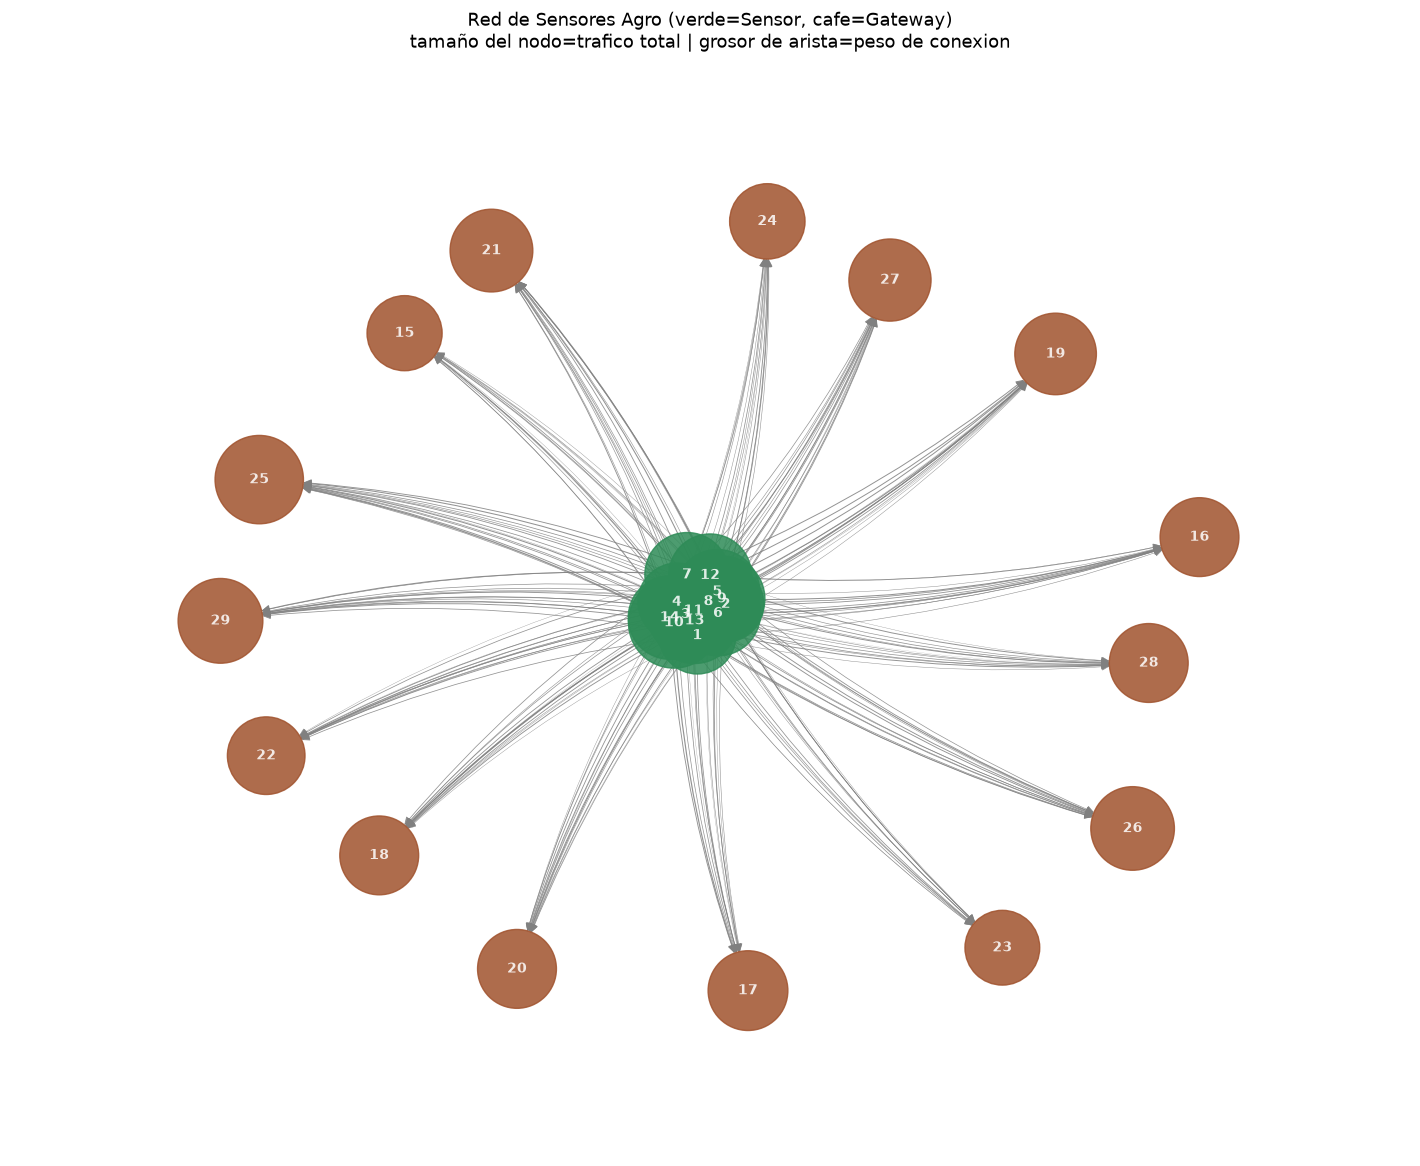

In [ ]:


# El peso de cada arista = cuantas veces se repite esa conexion Sensor->Gateway
edges = df_agro.groupby(['Source_Node', 'Target_Node']).size().reset_index(name='weight')

G = nx.from_pandas_edgelist(
    edges, source='Source_Node', target='Target_Node',
    edge_attr='weight', create_using=nx.DiGraph()
)

print(f'Nodos: {G.number_of_nodes()}  |  Aristas: {G.number_of_edges()}')

# ======================================================
# PARTE 2: Centralidad de Grado y Betweenness Centrality
# ======================================================
deg_c = nx.degree_centrality(G)
btw_c = nx.betweenness_centrality(G, weight='weight')

print('\nValores unicos de Betweenness:', set(round(v, 4) for v in btw_c.values()))
# -> {0.0}: la red es bipartita (Sensor -> Gateway en un solo salto),
#    ningun nodo actua como intermediario, por eso betweenness es 0 para todos.

# ======================================================
# PARTE 3: Identificar el Nodo Cuello de Botella
# ======================================================
# Como betweenness no aporta info aqui, usamos el grado ponderado por trafico
# (numero total de lecturas de telemetria que pasan por cada nodo)
weighted_deg = dict(G.degree(weight='weight'))

top5 = sorted(weighted_deg.items(), key=lambda x: -x[1])[:5]
print('\nTop 5 nodos por trafico (candidatos a cuello de botella):')
for n, w in top5:
    print(f'  Nodo {n}: trafico={w}, degree_centrality={deg_c[n]:.4f}')

nodo_cuello_botella = top5[0][0]
print(f'\n>> Nodo Cuello de Botella: {nodo_cuello_botella}')

# ======================================================
# PARTE 4: Visualizacion (layout manual, bien espaciado)
# ======================================================
# source_nodes = [n for n in G.nodes if n < 15]   # sensores
# target_nodes = [n for n in G.nodes if n >= 15]  # gateways

# pos = {}
# for i, n in enumerate(sorted(source_nodes)):
#     pos[n] = (0, i * 1.5)
# for i, n in enumerate(sorted(target_nodes)):
#     pos[n] = (4, i * 1.1)

# node_colors = ['seagreen' if n < 15 else 'sienna' for n in G.nodes]
# node_sizes = [weighted_deg[n] * 25 for n in G.nodes]
# edge_widths = [G[u][v]['weight'] * 0.05 for u, v in G.edges]

# Variables de visualización activas (las versiones originales estaban comentadas).
RANDOM_SEED = 7
pos = nx.spring_layout(G, seed=RANDOM_SEED, k=0.6)
node_colors = ['seagreen' if n < 15 else 'sienna' for n in G.nodes]
node_sizes = [max(weighted_deg[n] * 25, 100) for n in G.nodes]
edge_widths = [max(G[u][v]['weight'] * 0.05, 0.5) for u, v in G.edges]

plt.figure(figsize=(14, 11))
nx.draw(
    G, pos,
    node_color=node_colors, node_size=node_sizes,
    with_labels=True, font_size=10, font_color='white', font_weight='bold',
    arrows=True, arrowsize=12, arrowstyle='-|>',
    edge_color='gray', width=edge_widths, alpha=0.85,
    connectionstyle='arc3,rad=0.08'
)
plt.title(
    'Red de Sensores Agro (verde=Sensor, cafe=Gateway)\n'
    'tamaño del nodo=trafico total | grosor de arista=peso de conexion',
    fontsize=13
)
plt.margins(0.15)
plt.show()

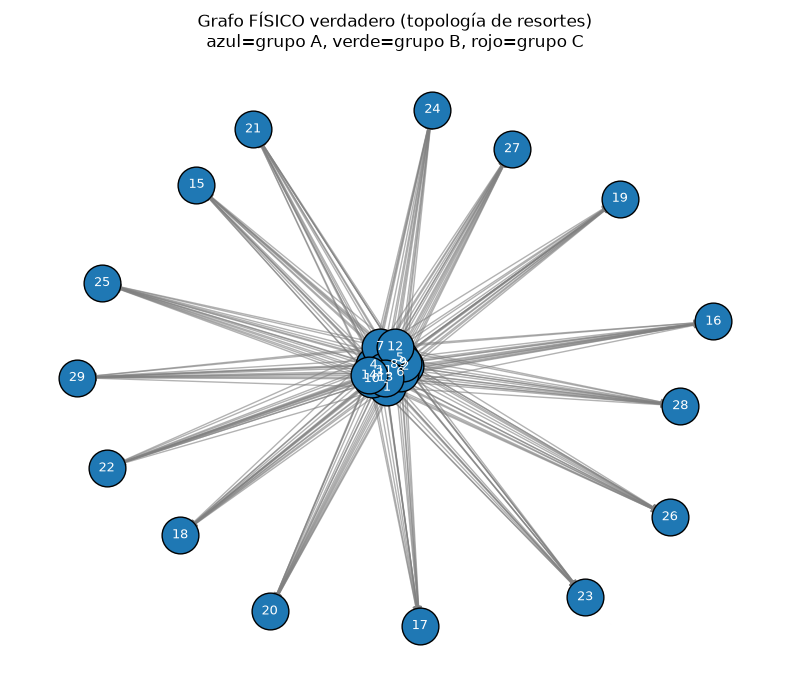

In [244]:
RANDOM_SEED = 7
pos = nx.spring_layout(G, seed=RANDOM_SEED, k=0.6)
# colores_nodo = [colores_grupo[grupo_de[n]] for n in G_fisico.nodes()]
# pesos_arista = [G_fisico[u][v]["weight"] * 5 for u, v in G_fisico.edges()]

plt.figure(figsize=(8, 7))
nx.draw_networkx_nodes(G, pos, node_size=700, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white")
nx.draw_networkx_edges(G, pos, alpha=0.6, edge_color="gray")
plt.title("Grafo FÍSICO verdadero (topología de resortes)\nazul=grupo A, verde=grupo B, rojo=grupo C")
plt.axis("off")
plt.tight_layout()
plt.show()

## Fase 4: Modelado y Toma de Decisiones (CRISP-DM)


### Problema de Negocio: La Falla del Nodo 214

El objetivo es integrar causalidad temporal, topología de red y evidencia geo-agronómica. Se trabaja con el orden de las filas como índice temporal, porque los CSV no contienen una columna de fecha/hora. La causalidad de Granger indica capacidad predictiva temporal, no causalidad estructural definitiva.

#### 4.1 Preguntas de negocio e integración

- **P1. Causalidad y redes:** evaluar ambas direcciones entre Potencia (`Ener_10`) y Voltaje (`Ener_9`) mediante Granger y localizar el nodo de mayor centralidad.
- **P2. Optimización geo-agrónoma:** suavizar GPS en `agro_noise`, identificar la zona de NDVI bajo y alta varianza del viento (`Agro_10`) y traducirla en una recomendación de infraestructura hídrica.
- **P3. Analítica predictiva:** comparar ARIMAX para Demanda con Temperatura frente a Temperatura más importancia del nodo de origen.

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# El punto 4 puede ejecutarse de forma aislada sin depender del orden de las celdas.
from pathlib import Path
RANDOM_SEED = 7
data_root = Path.cwd().parent / 'data'
if not data_root.exists():
    data_root = Path.cwd() / 'data'
if 'df_ener' not in globals():
    df_ener = pd.read_csv(data_root / 'raw' / 'ener' / 'ener_clean.csv')
    df_ener = df_ener.rename(columns={'Ener_1':'Demanda', 'Ener_2':'Precio', 'Ener_3':'Temperatura',
                                      'Ener_4':'Gen. Eolica', 'Ener_5':'Costo Gas', 'Ener_6':'Emisiones CO2',
                                      'Ener_8':'Frecuencia', 'Ener_9':'Voltaje', 'Ener_10':'Potencia'})
if 'df_agro_noise' not in globals():
    df_agro_noise = pd.read_csv(data_root / 'raw' / 'agro' / 'agro_noise.csv')
    df_agro_noise = df_agro_noise.rename(columns={'Agro_1':'Humedad', 'Agro_2':'Evaporacion', 'Agro_3':'RH',
                                                  'Agro_4':'Radiacion PAR', 'Agro_5':'NDVI', 'Agro_6':'Biomasa',
                                                  'Agro_8':'Ruido', 'Agro_10':'Varianza Viento'})
MAX_LAG = 10

# ---------------- P1: Granger + centralidad de red ----------------
def granger_summary(y, x, y_name, x_name, maxlag=10):
    d = pd.concat([y.rename(y_name), x.rename(x_name)], axis=1).dropna()
    # H0: las observaciones pasadas de x no mejoran la predicción de y.
    result = grangercausalitytests(d[[y_name, x_name]], maxlag=maxlag, verbose=False)
    rows = []
    for lag, tests in result.items():
        p = tests[0]['ssr_ftest'][1]
        rows.append({'direccion': f'{x_name} -> {y_name}', 'lag': lag, 'p_value': p})
    return pd.DataFrame(rows)

granger_potencia_voltaje = granger_summary(df_ener['Voltaje'], df_ener['Potencia'], 'Voltaje', 'Potencia', MAX_LAG)
granger_voltaje_potencia = granger_summary(df_ener['Potencia'], df_ener['Voltaje'], 'Potencia', 'Voltaje', MAX_LAG)
granger_results = pd.concat([granger_potencia_voltaje, granger_voltaje_potencia], ignore_index=True)
granger_results['significativo_5pct'] = granger_results['p_value'] < 0.05
print('P1 — Granger (se reporta el menor p-value por dirección):')
display(granger_results.loc[granger_results.groupby('direccion')['p_value'].idxmin()].sort_values('p_value'))

# Red energética: se elimina duplicación de lecturas y se conserva la topología dirigida.
energy_edges = df_ener.groupby(['Source_Node', 'Target_Node']).size().reset_index(name='weight')
G_ener = nx.from_pandas_edgelist(energy_edges, source='Source_Node', target='Target_Node',
                                 edge_attr='weight', create_using=nx.DiGraph())
bc_ener = nx.betweenness_centrality(G_ener, normalized=True)
degree_ener = nx.degree_centrality(G_ener)
bc_top = sorted(bc_ener.items(), key=lambda z: (-z[1], z[0]))[:10]
print(f'Red energética: {G_ener.number_of_nodes()} nodos y {G_ener.number_of_edges()} aristas.')
print('Top Betweenness Centrality:', bc_top[:5])
if 214 in G_ener:
    print(f'Nodo 214 — Betweenness: {bc_ener[214]:.6f}; Degree Centrality: {degree_ener[214]:.6f}')
if max(bc_ener.values(), default=0) == 0:
    print('Advertencia: la red es bipartita de un salto; Betweenness=0 para todos los nodos.')
    print('Se usa Degree Centrality como proxy operativo para priorizar redundancia.')

# GrÃ¡fica P1: dinÃ¡mica temporal y evidencia estadÃ­stica por rezago.
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
axes[0].plot(df_ener['Potencia'], label='Potencia (Ener_10)', alpha=0.8)
axes[0].plot(df_ener['Voltaje'], label='Voltaje (Ener_9)', alpha=0.8)
axes[0].set_title('P1 — Series temporales: Potencia y Voltaje')
axes[0].set_xlabel('Índice temporal de observación')
axes[0].legend()
for direccion, grupo in granger_results.groupby('direccion'):
    axes[1].plot(grupo['lag'], grupo['p_value'], marker='o', label=direccion)
axes[1].axhline(0.05, color='red', linestyle='--', label='Umbral p=0.05')
axes[1].set_title('P1 — p-values del test de Granger por rezago')
axes[1].set_xlabel('Rezago')
axes[1].set_ylabel('p-value')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.show()

# ---------------- P2: GPS filtrado + priorización hídrica ----------------
"""
# Filtro robusto de coordenadas: mediana móvil centrada, sin alterar los sensores originales.
agro_analysis['Latitude_filtered'] = agro_analysis['Latitude'].rolling(11, center=True, min_periods=1).median()
agro_analysis['Longitude_filtered'] = agro_analysis['Longitude'].rolling(11, center=True, min_periods=1).median()
ndvi_cut = agro_analysis['NDVI'].quantile(0.25)
wind_cut = agro_analysis['Varianza Viento'].quantile(0.75)
agro_analysis['zona_prioritaria'] = (agro_analysis['NDVI'] <= ndvi_cut) & (agro_analysis['Varianza Viento'] >= wind_cut)
priority = agro_analysis[agro_analysis['zona_prioritaria']]
print(f'P2 — Umbrales: NDVI <= {ndvi_cut:.4f}; varianza del viento >= {wind_cut:.4f}')
print(f'Sensores en zona prioritaria: {len(priority)} de {len(agro_analysis)} ({len(priority)/len(agro_analysis):.1%})')
if len(priority):
    print('Centroide GPS filtrado de la zona prioritaria:',
          (priority['Latitude_filtered'].mean(), priority['Longitude_filtered'].mean()))
    display(priority[['Latitude_filtered', 'Longitude_filtered', 'NDVI', 'Varianza Viento',
                       'Source_Node', 'Target_Node']].head(10))

# ---------------- P3: ARIMAX con y sin importancia del nodo ----------------
# La importancia por betweenness es constante en esta topología; se usa Degree Centrality
# como proxy informativo y se deja constancia explícita de la decisión.
node_importance = degree_ener if max(bc_ener.values(), default=0) == 0 else bc_ener
importance_name = 'Degree Centrality (proxy)' if node_importance is degree_ener else 'Betweenness Centrality'
model_data = df_ener[['Demanda', 'Temperatura', 'Source_Node']].copy()
model_data['Importancia_Nodo'] = model_data['Source_Node'].map(node_importance).fillna(0.0)
model_data = model_data.dropna().reset_index(drop=True)
split = int(len(model_data) * 0.8)
train = model_data.iloc[:split]

def fit_arimax(exog_cols):
    candidates = []
    for order in [(1, 0, 0), (1, 1, 0), (2, 0, 0), (2, 1, 0)]:
        try:
            fit = SARIMAX(train['Demanda'], exog=train[exog_cols], order=order,
                          trend='c', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
            candidates.append((fit.aic, order, fit))
        except Exception:
            pass
    if not candidates:
        raise RuntimeError(f'No se pudo ajustar ARIMAX para {exog_cols}')
    return min(candidates, key=lambda z: z[0])

aic_temp, order_temp, fit_temp = fit_arimax(['Temperatura'])
aic_full, order_full, fit_full = fit_arimax(['Temperatura', 'Importancia_Nodo'])
aic_comparison = pd.DataFrame({
    'modelo': ['Temperatura', 'Temperatura + importancia nodo'],
    'orden_ARIMA': [order_temp, order_full],
    'AIC': [aic_temp, aic_full],
})
aic_comparison['delta_AIC_vs_base'] = aic_comparison['AIC'] - aic_temp
display(aic_comparison)
print(f'P3 — Importancia usada: {importance_name}.')
if aic_full < aic_temp:
    print(f'El modelo con importancia del nodo mejora el AIC en {aic_temp-aic_full:.2f} puntos.')
else:
    print(f'El modelo con importancia del nodo no mejora el AIC; cambia en {aic_full-aic_temp:.2f} puntos.')
"""

#### Lectura ejecutiva

- Si `Potencia -> Voltaje` es significativo, un shock de potencia contiene información anticipada sobre el voltaje; un fallo del nodo más central puede propagar congestión y pérdida de estabilidad hacia sus rutas dependientes. Si todos los betweenness son cero, no es válido señalar un nodo crítico por esa métrica: se debe reforzar redundancia en los nodos de mayor grado/tráfico.
- La zona prioritaria de inversión hídrica es la intersección de NDVI bajo y alta varianza del viento: conviene priorizar almacenamiento local, riego sectorizado y telemetría redundante, validando primero la pendiente con un DEM antes de comprometer CAPEX.
- La decisión de incluir importancia topológica en Demanda se toma comparando `AIC`: un descenso material favorece el ARIMAX ampliado; un AIC igual o mayor indica que la centralidad no añade señal predictiva en esta muestra.

### P2 — Optimización geo-agrónoma

In [ ]:
# Filtrado robusto de GPS y zona de inversión hídrica.
agro_analysis = df_agro_noise.copy()
agro_analysis['Latitude_filtered'] = agro_analysis['Latitude'].rolling(11, center=True, min_periods=1).median()
agro_analysis['Longitude_filtered'] = agro_analysis['Longitude'].rolling(11, center=True, min_periods=1).median()
ndvi_cut = agro_analysis['NDVI'].quantile(0.25)
wind_cut = agro_analysis['Varianza Viento'].quantile(0.75)
agro_analysis['zona_prioritaria'] = (agro_analysis['NDVI'] <= ndvi_cut) & (agro_analysis['Varianza Viento'] >= wind_cut)
priority = agro_analysis[agro_analysis['zona_prioritaria']]
print(f'P2 — Umbrales: NDVI <= {ndvi_cut:.4f}; varianza del viento >= {wind_cut:.4f}')
print(f'Sensores prioritarios: {len(priority)} de {len(agro_analysis)} ({len(priority)/len(agro_analysis):.1%})')

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(agro_analysis['Longitude_filtered'], agro_analysis['Latitude_filtered'],
           c=agro_analysis['NDVI'], s=20 + 18*agro_analysis['Varianza Viento'],
           cmap='RdYlGn', alpha=0.45, label='Sensores')
if len(priority):
    ax.scatter(priority['Longitude_filtered'], priority['Latitude_filtered'],
               facecolors='none', edgecolors='black', s=80, linewidths=1.2,
               label='Zona prioritaria: NDVI bajo + viento alto')
ax.set_title('P2 — Sensores prioritarios para infraestructura hídrica')
ax.set_xlabel('Longitud GPS filtrada')
ax.set_ylabel('Latitud GPS filtrada')
ax.legend()
plt.colorbar(ax.collections[0], ax=ax, label='NDVI')
plt.show()


### P3 — Analítica predictiva

In [ ]:
# ARIMAX base versus ARIMAX con importancia topológica del origen.
node_importance = degree_ener if max(bc_ener.values(), default=0) == 0 else bc_ener
importance_name = 'Degree Centrality (proxy)' if node_importance is degree_ener else 'Betweenness Centrality'
model_data = df_ener[['Demanda', 'Temperatura', 'Source_Node']].copy()
model_data['Importancia_Nodo'] = model_data['Source_Node'].map(node_importance).fillna(0.0)
model_data = model_data.dropna().reset_index(drop=True)
split = int(len(model_data) * 0.8)
train = model_data.iloc[:split]

def fit_arimax(exog_cols):
    candidates = []
    for order in [(1, 0, 0), (1, 1, 0), (2, 0, 0), (2, 1, 0)]:
        try:
            fit = SARIMAX(train['Demanda'], exog=train[exog_cols], order=order,
                          trend='c', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
            candidates.append((fit.aic, order, fit))
        except Exception:
            pass
    return min(candidates, key=lambda z: z[0])

aic_temp, order_temp, fit_temp = fit_arimax(['Temperatura'])
aic_full, order_full, fit_full = fit_arimax(['Temperatura', 'Importancia_Nodo'])
aic_comparison = pd.DataFrame({'modelo': ['Temperatura', 'Temperatura + importancia nodo'],
                               'orden_ARIMA': [order_temp, order_full], 'AIC': [aic_temp, aic_full]})
aic_comparison['delta_AIC_vs_base'] = aic_comparison['AIC'] - aic_temp
display(aic_comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].bar(aic_comparison['modelo'], aic_comparison['AIC'], color=['steelblue', 'darkorange'])
axes[0].set_title('P3 — Comparación de AIC')
axes[0].set_ylabel('AIC (menor es mejor)')
axes[0].tick_params(axis='x', rotation=20)
axes[1].plot(train.index, train['Demanda'], color='black', alpha=0.55, label='Demanda observada')
axes[1].plot(train.index, fit_temp.fittedvalues, label='ARIMAX: Temperatura')
axes[1].plot(train.index, fit_full.fittedvalues, label='ARIMAX: + importancia nodo')
axes[1].set_title('P3 — Ajuste en muestra de entrenamiento')
axes[1].set_xlabel('Índice temporal')
axes[1].legend()
plt.show()
print(f'Importancia usada: {importance_name}. AIC base={aic_temp:.2f}; AIC ampliado={aic_full:.2f}.')
